# Partisan attention to science — PoC

**Research question:** what attributes of published science (funding, prestige, field) are
associated with *partisan* attention on social media and in the news?

**Track A (works):** publications that US members of Congress amplify, via Altmetric mention-level
data joined to Dimensions. Validated: **412 publications amplified by 145 members** (≈balanced
D/R), with a striking partisan split by field, plus funder, institution (ROR→prestige), grant, and
news/policy enrichment.

**Track B (fallback / comparison):** keyword corpus, same attribute pipeline.

**Cost discipline:** the Dimensions/Altmetric tables are large Analytics Hub *linked* datasets, so a
dry run returns **no byte estimate** and `TEMP TABLE`/exports are blocked. The guardrail is a hard
`maximum_bytes_billed` cap in `poclib.gbq.run_guarded`: BigQuery **aborts before billing** above
`MAX_QUERY_GIB` (and the error reveals the true size). Big tables are partition-pruned (`year`) and
referenced by leaf columns only; results cache to `output-data/*.parquet`.

**Caveats:** X collection ended ~mid-2023; Bluesky handles aren't in the legislators file; news
(`msm`)+policy have continuous coverage but no intrinsic party — outlet lean needs a media-bias
roster (`input-data/media_bias.csv`).

In [ ]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
%load_ext autoreload
%autoreload 2
import pandas as pd
from poclib import config, gbq, schema_discovery, congress, analysis
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 180)

## 0 — Config & auth
Auth uses ADC for the account the data is shared with, billing to a project that account can run
jobs in:
```
gcloud auth application-default login --account=<account-with-data-access>
gcloud auth application-default set-quota-project <BILLING_PROJECT>
```

In [ ]:
print("Billing :", config.BILLING_PROJECT)
print("Dimensions:", config.DIMENSIONS_DATASET)
print("Altmetric :", config.ALTMETRIC_DATASET)
print("Max GiB  :", config.MAX_QUERY_GIB)
client = gbq.get_client()
print("client ready, billing to:", client.project)

## 1 — Altmetric three-table model
- **attention_sources** — account: `type` (`tw`/`bsk`/`msm`/`policy`/...), `social_media.screen_name`.
- **posts** — mention: `attention_source_id`, `type`, `attention_source.{name,country}`, `url`,
  `identifiers.dimensions.publication_ids`.
- **research_outputs** — per output: `altmetric_score`, `mentions.*` channel counts.

In [ ]:
schema_discovery.list_tables(config.ALTMETRIC_DATASET)

In [ ]:
schema_discovery.describe_table(config.ALTMETRIC_DATASET, "attention_sources")

## 2 — Congress roster (party + handles)

In [ ]:
roster = congress.load_roster()
print("legislators:", len(roster), "| twitter:", roster["twitter"].notna().sum(),
      "| bluesky:", roster["bluesky"].notna().sum())
display(roster.groupby(["chamber","party"]).size().unstack(fill_value=0))
handles = congress.lowercased_handle_set(roster)
handle_to_member = congress.handle_party_map(roster)
print("distinct handles:", len(handles))

## 3 — Track A: publications amplified by Congress

In [ ]:
handles_list = gbq.quote_for_in_clause(sorted(handles))
amp_sql = gbq.load_sql("congress_amplified_pubs", altmetric_dataset=config.ALTMETRIC_DATASET,
                       handles_list=handles_list, row_limit=2_000_000)
amplified = gbq.run_guarded(amp_sql)
amplified["party"]  = amplified["screen_name"].map(lambda h: handle_to_member.get(h, {}).get("party"))
amplified["member"] = amplified["screen_name"].map(lambda h: handle_to_member.get(h, {}).get("full_name"))
amplified.to_parquet(config.OUTPUT_DIR / "congress_amplified_mentions.parquet", index=False)
print("mentions:", len(amplified), "| pubs:", amplified["pub_id"].nunique(),
      "| members:", amplified["member"].nunique())
display(amplified["channel"].value_counts()); display(amplified["party"].value_counts(dropna=False))
display(amplified["member"].value_counts().head(10))

## 4 — Track A attributes: funders, fields, institutions, grants

`pub_attributes` scans `publications` once (leaf columns, pruned to `min_year`) and returns
funder/research GRID ids, FoR fields, supporting grant ids, and author surnames. GRID ids are
resolved (names, types, ROR, country) via the cheap `org_names` lookup.

In [ ]:
pub_ids = sorted(amplified["pub_id"].dropna().unique())
attr_sql = gbq.load_sql(
    "pub_attributes",
    pub_ids=gbq.quote_for_in_clause(pub_ids),
    min_year=2010,
    dimensions_dataset=config.DIMENSIONS_DATASET,
)
attributes = gbq.run_guarded(attr_sql)

org_ids = analysis.all_grid_ids(attributes)

In [12]:
attributes = pd.read_parquet(config.OUTPUT_DIR / "amplified_attributes.parquet")

In [19]:
org_lookup = gbq.run_guarded(gbq.load_sql("org_names",
                org_ids=gbq.quote_for_in_clause(org_ids), dimensions_dataset=config.DIMENSIONS_DATASET))
attributes = analysis.attach_org_names(attributes, org_lookup)
attributes.to_parquet(config.OUTPUT_DIR / "amplified_attributes.parquet", index=False)
print("pubs resolved:", attributes["pub_id"].nunique(), "of", len(pub_ids),
      f"({attributes['pub_id'].nunique()/len(pub_ids):.0%})  | orgs w/ ROR:",
      f"{org_lookup['ror'].notna().mean():.0%}")
attributes[["pub_id","year","for_name","source_title","n_authors","funder_names"]].head()

[dry-run] scan size not reported by dry-run (Analytics Hub linked dataset)


/Users/larremoreadmin/research/scieco/icssi-2026-hackathon/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


[billed] 0.000 GiB ($0.0000)
pubs resolved: 409 of 412 (99%)  | orgs w/ ROR: 97%


,pub_id,year,for_name,source_title,n_authors,funder_names
0,pub.1004751246,2022,Creative Arts and Writing,Scientific American,1,[]
1,pub.1004751246,2022,"Language, Communication and Culture",Scientific American,1,[]
2,pub.1056566186,2022,NaN,Scientific American,1,[]
3,pub.1138614686,2021,Biomedical and Clinical Sciences,medRxiv,5,[]
4,pub.1139078733,2021,Biological Sciences,bioRxiv,1,"[Howard Hughes Medical Institute, Office of th..."


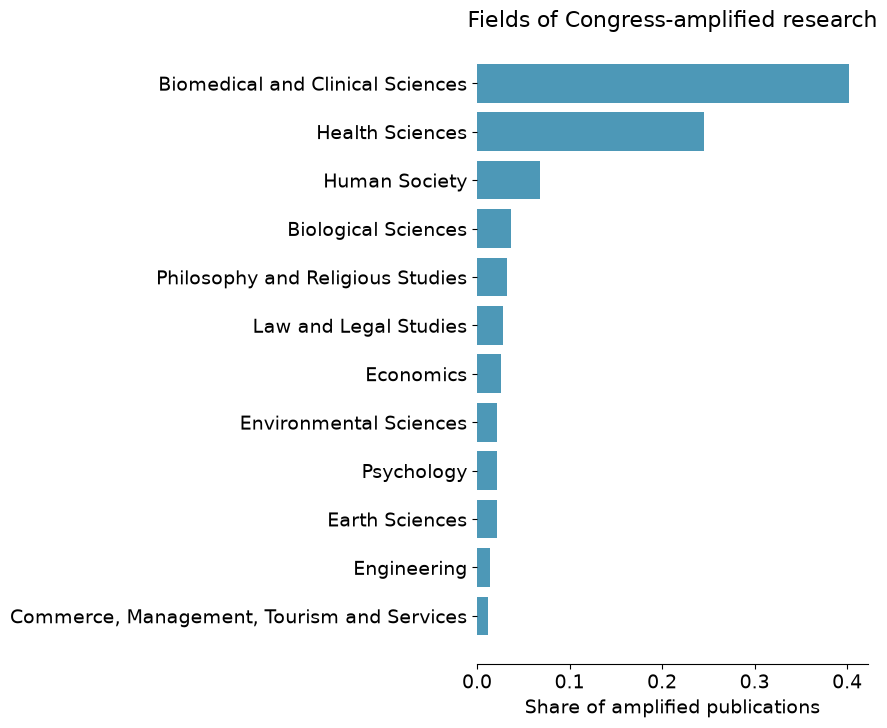

In [ ]:
# fields of amplified research
fig = analysis.plot_field_distribution(attributes.drop_duplicates(["pub_id","for_name"]), "for_name",
        title="Fields of Congress-amplified research")
analysis.save_fig(fig, "amplified_field_distribution")


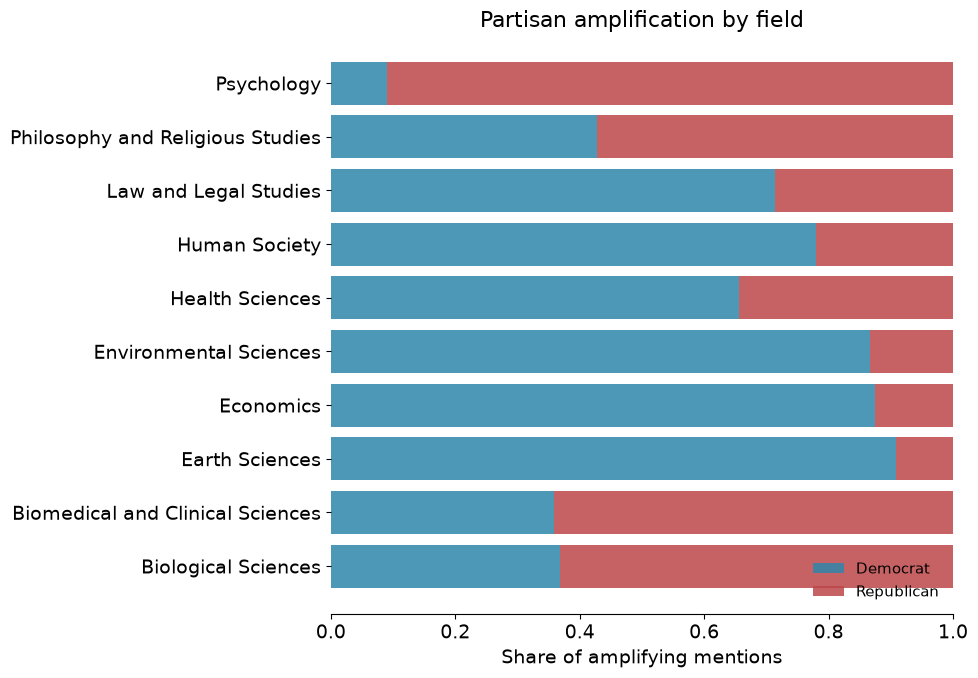

In [15]:
# partisan split by field
mention_fields = amplified[["pub_id","party"]].merge(
    attributes[["pub_id","for_name"]].drop_duplicates(), on="pub_id")
split = analysis.partisan_field_split(mention_fields, "for_name", "party", top_n=10)
fig = analysis.plot_partisan_field_split(split, title="Partisan amplification by field")
analysis.save_fig(fig, "amplified_partisan_field_split")

In [16]:
# funders + funder types
display(analysis.share_table(attributes.drop_duplicates("pub_id").explode("funder_names"),"funder_names",12))
display(analysis.share_table(attributes.drop_duplicates("pub_id").explode("funder_types"),"funder_types",10))

,count,share
funder_names,,
Centers for Disease Control and Prevention,25,0.052854
National Institute of Allergy and Infectious Diseases,20,0.042283
Wellcome Trust Ltd,11,0.023256
National Center for Advancing Translational Sciences,11,0.023256
Eunice Kennedy Shriver National Institute of Child Health and Human Development,10,0.021142
Gates Foundation,9,0.019027
National Institute on Aging,9,0.019027
National Heart Lung and Blood Institute,9,0.019027
National Cancer Institute,8,0.016913


,count,share
funder_types,,
Government,136,0.583691
Nonprofit,59,0.253219
Education,11,0.047210
Facility,10,0.042918
Company,8,0.034335
Healthcare,8,0.034335
Other,1,0.004292


### 4a — Institutional affiliations → ROR → prestige

`research_grids` (author-affiliation GRID ids) resolved to names + ROR, then joined to the
ROR-keyed prestige crosswalk in `input-data/`.

In [20]:
institutions = analysis.institutions_long(attributes, org_lookup)
institutions.to_parquet(config.OUTPUT_DIR / "amplified_institutions.parquet", index=False)
print("(pub x institution) rows:", len(institutions), "| ROR coverage:",
      f"{institutions['ror'].notna().mean():.0%}")
display(analysis.share_table(institutions.drop_duplicates(["pub_id","grid_id"]),"institution_name",12))

(pub x institution) rows: 1228 | ROR coverage: 98%


,count,share
institution_name,,
Harvard University,26,0.021173
Centers for Disease Control and Prevention,17,0.013844
University of Oxford,14,0.011401
Yale University,13,0.010586
Emory University,13,0.010586
Johns Hopkins University,13,0.010586
Epidemic Intelligence Service,13,0.010586
University of Washington,12,0.009772
Stanford University,12,0.009772


In [21]:
# join external prestige (by ROR) and compare across amplifying party
prestige = analysis.load_prestige()
inst_prestige = analysis.attach_prestige(institutions, prestige)
print("prestige matched:", f"{inst_prestige['normalized_ordinal_prestige'].notna().mean():.0%}",
      "of institution rows")
pub_prestige = inst_prestige.groupby("pub_id")["normalized_ordinal_prestige"].mean().rename("mean_prestige")
mp = amplified[["pub_id","party"]].drop_duplicates().merge(pub_prestige, on="pub_id")
display(mp.groupby("party")["mean_prestige"].agg(["mean","median","count"]).round(3))

prestige matched: 25% of institution rows


,mean,median,count
party,,,
Democrat,0.887,0.939,78
Republican,0.881,0.941,73


### 4b — Grants

`supporting_grant_ids` (from the publications scan) resolved to grant records: funder, amount
(USD), period.

In [ ]:
grant_ids = analysis.all_grant_ids(attributes)
grants = gbq.run_guarded(
    gbq.load_sql(
        "grants_for_pubs",
        grant_ids=gbq.quote_for_in_clause(grant_ids),
        dimensions_dataset=config.DIMENSIONS_DATASET,
    )
)
grants_long = analysis.grants_long(attributes, grants, org_lookup)
grants_long.to_parquet(config.OUTPUT_DIR / "amplified_grants.parquet", index=False)

In [22]:
grants_long = pd.read_parquet(config.OUTPUT_DIR / "amplified_grants.parquet")

In [24]:
print("unique grants:", grants_long.grant_id.nunique(), "| (pub x grant) rows:", len(grants_long),
      "| total USD: {:,.0f}".format(grants_long['funding_usd'].sum(min_count=1)))
print("\nTop grant funders by total USD:")
display(grants_long.groupby("funder_name")["funding_usd"].sum().sort_values(ascending=False).head(10))
# funding by amplifying party
gp = amplified[["pub_id","party"]].drop_duplicates().merge(grants_long, on="pub_id")
display(gp.groupby("party")["funding_usd"].agg(["sum","median","count"]))

unique grants: 267 | (pub x grant) rows: 299 | total USD: 21,675,303,613

Top grant funders by total USD:


funder_name
United States Department of Energy                       1.687058e+10
National Institute of Allergy and Infectious Diseases    1.953131e+09
National Center for Advancing Translational Sciences     8.770234e+08
Office of the Director                                   4.998975e+08
National Cancer Institute                                2.798463e+08
European Commission                                      2.334236e+08
National Institute on Alcohol Abuse and Alcoholism       1.182841e+08
National Institute on Aging                              9.155762e+07
National Institute of Environmental Health Sciences      8.933396e+07
Directorate for STEM Education                           8.726121e+07
Name: funding_usd, dtype: float64

,sum,median,count
party,,,
Democrat,1.099727e+09,3441217.0,105
Republican,2.057636e+10,3398591.5,190


## 5 — News & policy partisanship

Pull each amplified paper's news (`msm`) and policy mentions with outlet identity, derive the
domain, and join an external media-bias roster (`input-data/media_bias.csv`, columns e.g.
`domain,lean`) to assign each outlet a partisan lean.

In [ ]:
np_sql = gbq.load_sql(
    "news_policy_mentions",
    altmetric_dataset=config.ALTMETRIC_DATASET,
    pub_ids=gbq.quote_for_in_clause(pub_ids),
    row_limit=500000,
)
news_policy = gbq.run_guarded(np_sql)
news_policy["domain"] = analysis.extract_domain(news_policy["url"])
news_policy.to_parquet(config.OUTPUT_DIR / "amplified_news_policy.parquet", index=False)

In [26]:
news_policy = pd.read_parquet(config.OUTPUT_DIR / "amplified_news_policy.parquet")
print("news/policy mentions:", len(news_policy))
display(news_policy["channel"].value_counts())
display(news_policy["domain"].value_counts().head(12))

news/policy mentions: 79505


channel
msm       76620
policy     2885
Name: count, dtype: int64

domain
ct.moreover.com        6759
msn.com                2013
news.yahoo.com         1219
newsbreak.com          1066
yahoo.com               842
stacks.cdc.gov          760
nytimes.com             738
theconversation.com     528
dnyuz.com               497
theepochtimes.com       490
uk.news.yahoo.com       475
washingtonpost.com      446
Name: count, dtype: int64

In [28]:
bias_path = config.INPUT_DIR / "media_bias.csv"
if bias_path.exists():
    bias = analysis.load_media_bias()
    np_bias = analysis.attach_media_bias(news_policy, bias, on="domain")
    print("outlet bias matched:", f"{np_bias['bias'].notna().mean():.0%}", "of mentions")
    # do R-amplified vs D-amplified papers get covered by differently-leaning outlets?
    party = amplified[["pub_id","party"]].drop_duplicates()
    xtab = np_bias.merge(party, on="pub_id").pivot_table(
        index="bias", columns="party", values="pub_id", aggfunc="count", fill_value=0)
    display(xtab.div(xtab.sum(), axis=1).round(2))   # bias distribution within each party
else:
    print("Provide input-data/media_bias.csv (e.g. columns: domain,lean) to assign outlet lean.")
    print("Top domains above are ready to match.")

outlet bias matched: 43% of mentions


party,Democrat,Republican
bias,,
left,0.04,0.03
left-center,0.41,0.39
neutral,0.44,0.41
right,0.03,0.07
right-center,0.08,0.09


## 7 — Optional: enrich author attributes from a CV (Claude API)
Requires `ANTHROPIC_API_KEY`.

In [ ]:
if config.ANTHROPIC_API_KEY:
    from poclib import cv_extract
    demo_cv = """Jane Q. Researcher. Associate Professor of Climate Science, MIT.
    PhD, Stanford University, 2012. NSF CAREER awardee (2018). Sloan Research Fellow.
    Funding: NSF, Department of Energy, Gordon and Betty Moore Foundation."""
    print(cv_extract.extract_cv(demo_cv))
else:
    print("Set ANTHROPIC_API_KEY in .env to run the CV demo.")

## 8 — Findings & next steps
- **Fields:** Biomedical/Clinical (~40%) + Health Sciences (~25%) dominate Congress-amplified work.
- **Funders:** ~58% government (CDC, NIAID, Gates, Wellcome); grants pull adds funder/amount.
- **Partisanship (fields):** Economics / Environmental / Human Society skew Democrat; Biomedical &
  Biological Sciences skew Republican.
- **Institutions:** Harvard/CDC/Oxford/Johns Hopkins lead; ROR→prestige join ready (expand the
  crosswalk for fuller coverage).
- **News/policy:** outlet domains pulled; supply `media_bias.csv` to quantify outlet lean.
Next: per-author affiliation (corresponding author), grant funder *type* mix by party, scale the CV
module, and compare amplified vs keyword baselines.